In [ ]:
# --- Setup: make the `ecp` support package available -----------------
# Colab opens a single notebook and installs nothing, so fetch `ecp` from
# the public repo if it isn't importable yet. On Binder/local it is already
# installed, so this cell is a fast no-op there.
try:
    import ecp  # noqa: F401
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "git+https://github.com/ramador09/elementary-computational-physics-public@main"],
        check=True,
    )


# 7.3 Learning the Potential

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Chapter VII — Data and Descriptors",
    number="7.3",
    title="Learning the Potential",
    blurb="The two previous notebooks built descriptors and asked how to choose "
    "training points. This one closes the loop: it actually fits a potential — by "
    "exact linear algebra, no black box — and then does the more important thing, "
    "which is to find out precisely where and how the fitted model fails.",
    difficulty="advanced",
    estimate="90–120 min",
    source="FS 2023 · Lectures 10–11 (machine learning for atomistic systems)",
)

<ECP header: 2894 chars of HTML>

## Notebook overview

[§7.1](structural-descriptors.ipynb) turned an atomic structure into a vector a
model can accept, and [§7.2](dimensionality-reduction.ipynb) ended on a pointed
question: is a training set chosen to *cover* descriptor space the set you would
want to *fit a model* to? Answering it requires a model, so this notebook builds
the whole supervised-learning pipeline for a potential energy surface, end to end
and with nothing imported from a machine-learning library: a labelled dataset of
Lennard-Jones cluster configurations, a global descriptor assembled from the
symmetry functions of §7.1, and **kernel ridge regression** solved by exact linear
algebra {cite}`rupp2012`. Because the labelling oracle here is the Lennard-Jones
energy of [§2.1](../02-energy-landscapes/lennard-jones-clusters.ipynb) rather than
a day of density-functional theory, we can afford the truth for every prediction —
which makes this the honest laboratory for studying the *method*, exactly as a
production team would prototype on a cheap surrogate before spending real compute.

Three lessons structure the notebook. A dataset is a *curated* object: one
careless configuration with two overlapping atoms carries a wall energy of
thousands of ε and poisons every regression it touches. A kernel model is exact
linear algebra with two analytic limits, so it can be certified before it is
trusted. And a fitted potential fails *silently* outside its training domain,
returning confident numbers with no error bars; the red flag that exposes the
failure is not in the predictions at all, but in the distance between the query
and the training set.

> **Provenance.** This notebook develops **Lecture 10** and **Lecture 11** of the
> course (machine learning for atomistic systems; sampling), an exercise
> **designed by the author (Raymond Amador)** to complete the chapter that
> restores those lectures. Like its two companions it uses no committed
> calculation: the oracle, the descriptors, and the model are all built here, so
> every number can be re-derived from scratch. The full course credit is in the
> footer.

> **Reading a validation.** Each exercise closes with a check against an
> independent fact: a literature minimum energy, an analytic limit of the
> regression, a monotonicity the theory demands, a failure the theory predicts.
> A ✗ flags a mismatch to investigate; a ✓ is strong evidence, not proof.

> **Scope.** We fit energies of one cluster size with one descriptor and one
> kernel, because the pathologies worth teaching (dataset poisoning,
> regularisation limits, extrapolation failure) appear already in the smallest
> honest example. Forces, multiple elements, and production descriptor sets are
> surveyed in the Outlook.

## Theory in brief

### The supervised-learning frame

Every method in this course computes the energy of a configuration from first
principles, at a cost that repeats for every configuration. Machine-learning
potentials {cite}`behler2007,bartok2010` propose to pay that cost only $n$ times:
evaluate an expensive oracle on a **training set** of configurations, then fit a
cheap surrogate that generalises to configurations the oracle never saw. The
ingredients are a dataset $\{(\mathbf{x}_i, E_i)\}_{i=1}^{n}$, where
$\mathbf{x}_i$ is a fixed-length descriptor of configuration $i$ and $E_i$ its
oracle energy, and a regression model mapping descriptor to energy. Everything
in this notebook is about what those two ingredients hide.

### Kernel ridge regression

A linear fit in descriptor space is too rigid for a potential energy surface, but
a linear fit in a *nonlinearly transformed* space is not. The kernel trick makes
that transformation implicit: choose a kernel $k(\mathbf{x}, \mathbf{x}')$
measuring the similarity of two configurations, and write the prediction as a
kernel expansion over the training set,

```{math}
:label: eq-lp-krr-model
\hat{E}(\mathbf{x}) \;=\; \bar{E} \;+\; \sum_{i=1}^{n} \alpha_i\,
k(\mathbf{x}_i, \mathbf{x}),
```

with $\bar{E}$ the training-set mean, subtracted so the model only has to learn
deviations from it. Requiring the least-squares residual plus a ridge penalty
$\lambda \sum_i \alpha_i^2$ to be minimal gives the coefficients as the solution
of one linear system {cite}`rupp2012`,

```{math}
:label: eq-lp-krr-alpha
(K + \lambda I)\,\boldsymbol{\alpha} \;=\; \mathbf{E} - \bar{E},
\qquad K_{ij} = k(\mathbf{x}_i, \mathbf{x}_j),
```

and for the similarity measure we use the radial-basis-function kernel with a
single length scale $\gamma$ in (standardised) descriptor space,

```{math}
:label: eq-lp-rbf
k(\mathbf{x}, \mathbf{x}') \;=\;
\exp\!\left(-\,\frac{\lVert \mathbf{x} - \mathbf{x}' \rVert^2}{2\gamma^2}\right).
```

The ridge parameter $\lambda$ is usually introduced as a guard against noise, but
our labels are *exact* (the oracle is deterministic), and $\lambda$ still
matters, twice over. Analytically it interpolates between two limits the model
can be certified against: as $\lambda \to \infty$ the coefficients are crushed to
zero and Eq. {eq}`eq-lp-krr-model` returns the constant $\bar{E}$, while as
$\lambda \to 0$ the system forces $K\boldsymbol{\alpha} = \mathbf{E} - \bar{E}$
and the model passes through every training point exactly. Numerically, $\lambda$
sets the conditioning of the matrix in Eq. {eq}`eq-lp-krr-alpha`: two nearly
identical training configurations make two nearly identical rows of $K$, and
without the ridge the solve amplifies rounding error into wild coefficients.
Both faces of $\lambda$ appear as measurements below.

### What the model cannot tell you

Eq. {eq}`eq-lp-krr-model` is a weighted sum of Gaussians centred on the training
points. A query far from every training point in descriptor space sees every
kernel value near zero, so the prediction relaxes toward $\bar{E}$ regardless of
the true energy: the model *extrapolates toward its mean*, silently. The honest
companion of a kernel potential is therefore not an error bar it cannot produce,
but the distance from the query to its nearest training neighbour, which costs
one row of kernel evaluations and flags the failure before it happens.

---
## Setup

The Setup below holds this notebook's data and instruments — nothing you are
asked to build. It is collapsed so the building stays yours; expand it whenever
you want the details.

<!-- setup-policy: v2 -->

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import minimize
from scipy.stats import spearmanr

from ecp import validate

INK, AMBER, SOFT = "#16213e", "#c0851a", "#46506b"

# data: natural Lennard-Jones units throughout — energies in epsilon, lengths in
# sigma. The literature global-minimum energy of the 13-atom cluster (the
# icosahedron) is the external anchor for the relaxation of Exercise 1.
E_LJ13 = -44.326801  # data: LJ13 global minimum, Wales & Doye (1997)

# data: the descriptor table of §7.1 — eight radial symmetry functions G2, each a
# (width eta, centre Rs) pair, cut off at RC. Chosen to tile distances from the
# first neighbour shell (r ~ 1.1) out to the cluster diameter.
G2_ETAS = np.array([0.05, 0.15, 0.35, 0.8, 1.6, 3.0, 6.0, 12.0])
G2_RS = np.array([1.0, 1.0, 1.0, 1.1, 1.3, 1.6, 2.0, 2.4])
G2_RC = 2.8  # data: cutoff radius in sigma; encloses the whole 13-atom cluster

# data: the dataset design of Exercise 1. Training amplitudes stay inside the
# quasi-harmonic regime; the far amplitudes of Exercise 4 are deliberately outside
# it. The distance floor DMIN is the curation rule: no configuration enters any
# dataset with a pair closer than 0.95 sigma, where the pair repulsion is still a
# modest ~2 epsilon rather than the thousands the r^-12 wall reaches at overlap.
AMPS_TRAIN = np.array([0.02, 0.04, 0.06, 0.08, 0.10, 0.12])
AMPS_FAR = np.array([0.18, 0.24])
DMIN = 0.95


def lj_energy_gradient(x):
    """Total Lennard-Jones energy and its gradient for a flat coordinate vector.

    Built from scratch in §2.1; restated here as an instrument — it is this
    notebook's labelling oracle, not its lesson. Natural units (epsilon = sigma
    = 1), so V(r) = 4 (r^-12 - r^-6) summed over all pairs.

    Parameters
    ----------
    x : numpy.ndarray
        Flat coordinates, shape (3 n_atoms,).

    Returns
    -------
    tuple
        ``(E, grad)``: the total energy (float, in epsilon) and its gradient
        with respect to ``x``, shape (3 n_atoms,).
    """
    # Pairwise separations by broadcasting; the infinite diagonal removes the
    # self-pair from every sum without an index mask.
    pos = x.reshape(-1, 3)
    diff = pos[:, None, :] - pos[None, :, :]
    r = np.sqrt((diff**2).sum(axis=-1))
    np.fill_diagonal(r, np.inf)
    inv6 = r**-6
    # Factor 2 (not 4): the full matrix counts every pair twice, so 4/2 = 2.
    energy = 2.0 * np.sum(inv6 * (inv6 - 1.0))
    # dV/dr assembled on the same matrix; summing the pair forces over j gives
    # the gradient on atom i in one contraction.
    grad = (-(24.0 * (2.0 * inv6**2 - inv6) / r**2)[:, :, None] * diff).sum(axis=1)
    return energy, grad.ravel()


def global_fingerprint(pos):
    """Global descriptor: per-atom G2 symmetry functions summed over the cluster.

    The per-atom G2 of §7.1 (a Gaussian of width eta centred at Rs on the
    neighbour distances, smoothly cut off at G2_RC) is built from scratch there;
    restated here as an instrument and summed over atoms, which keeps the vector
    length fixed and makes it permutation-invariant by construction.

    Parameters
    ----------
    pos : numpy.ndarray
        Atomic positions, shape (n_atoms, 3), in sigma.

    Returns
    -------
    numpy.ndarray
        The 8-component fingerprint, one entry per (eta, Rs) row of the table.
    """
    diff = pos[:, None, :] - pos[None, :, :]
    r = np.sqrt((diff**2).sum(axis=-1))
    np.fill_diagonal(r, np.inf)
    # The cutoff is evaluated ONLY where r < G2_RC: the infinite diagonal
    # padding must never reach np.cos, which returns NaN at infinity and would
    # silently poison every feature.
    fc = np.zeros_like(r)
    inside = r < G2_RC
    fc[inside] = 0.5 * (np.cos(np.pi * r[inside] / G2_RC) + 1.0)
    # Factor 1/2 for the double-counted pairs, as in the energy.
    return np.array(
        [
            np.sum(np.exp(-eta * (r - rs) ** 2) * fc) / 2.0
            for eta, rs in zip(G2_ETAS, G2_RS)
        ]
    )


def farthest_point_sampling(X, k, start=0):
    """Indices of ``k`` rows of ``X`` chosen by farthest-point sampling.

    Built from scratch in §7.2; restated here as an instrument. Greedy: each new
    point is the one whose distance to the already-selected set is largest.

    Parameters
    ----------
    X : numpy.ndarray
        Data matrix, one point per row.
    k : int
        Number of points to select.
    start : int, optional
        Index of the first selected point.

    Returns
    -------
    numpy.ndarray
        The ``k`` selected row indices, in selection order.
    """
    selected = [start]
    dist = np.linalg.norm(X - X[start], axis=1)
    for _ in range(k - 1):
        j = int(np.argmax(dist))
        selected.append(j)
        dist = np.minimum(dist, np.linalg.norm(X - X[j], axis=1))
    return np.array(selected)


def min_pair_distance(pos):
    # instrument: the curation criterion of Exercise 1 — the smallest interatomic
    # distance in a configuration; one broadcast, not the lesson.
    diff = pos[:, None, :] - pos[None, :, :]
    r = np.sqrt((diff**2).sum(axis=-1))
    np.fill_diagonal(r, np.inf)
    return float(r.min())


def rmse(a, b):
    # instrument: root-mean-square difference, the error measure used throughout.
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

---
## Exercise 1 — A dataset is a curated object

Before any learning happens, someone has to decide *which* configurations the
oracle labels, and this decision is physics, not bookkeeping. Sampling
displacements around a minimum is the standard way to cover the configurations
a simulation at modest temperature would visit. But a Gaussian displacement has
no respect for the $r^{-12}$ wall: rattle hard enough and eventually two atoms
land nearly on top of each other, and a single such configuration carries an
energy of thousands of ε. Fed to a least-squares fit, whose loss is quadratic
in the residual, that one point outweighs the entire physical dataset. Real
machine-learning-potential pipelines therefore *reject* unphysical geometries
before labelling, exactly as we do here.

**Part a)** Recover the reference structure: minimise the 13-atom Lennard-Jones
cluster with `scipy.optimize.minimize(method="L-BFGS-B", jac=True)` on the
`lj_energy_gradient` oracle from the Setup, from 40 random starts drawn as
`numpy.random.default_rng(0).normal(scale=0.8, size=39)`. Keep the best
minimum as the icosahedral reference $E_0$, and also keep the lowest minimum
lying at least $0.5\,\varepsilon$ above $E_0$: Exercise 3 needs a second basin.

**Part b)** Build the curated training pool: for each amplitude $A$ in
`AMPS_TRAIN` $= \{0.02, \dots, 0.12\}\,\sigma$, draw Gaussian rattles of the
reference (`numpy.random.default_rng(1)`, `scale=A`) and keep the first 70
whose `min_pair_distance` is at least `DMIN` $= 0.95\,\sigma$, labelling each
kept configuration with its oracle energy. Then build the cautionary control:
200 rattles at $A = 0.12\,\sigma$ from `numpy.random.default_rng(7)` with **no
distance floor**, labelled the same way. Report the energy range of both sets.

**Part c)** Fingerprint the curated pool with `global_fingerprint` and
standardise the features: $Z = (X - \mu)/s$ with $\mu$ and $s$ the per-feature
mean and standard deviation over the pool, applied by broadcasting. (The RBF
kernel of Eq. {eq}`eq-lp-rbf` uses one length scale for all features, so
features must first be brought to a common scale.)

global minimum   E0 = -44.326801 eps   (literature -44.326801)
second basin     E1 = -41.471980 eps   (E1 - E0 = 2.855)
curated pool: 420 configs, E in [-43.75, -22.06] eps (8957 rejected by the floor)
uncurated control: 200 configs, E in [-32.49, 10273.5] eps, 156 above zero
fingerprints: 420 x 8, all finite: True


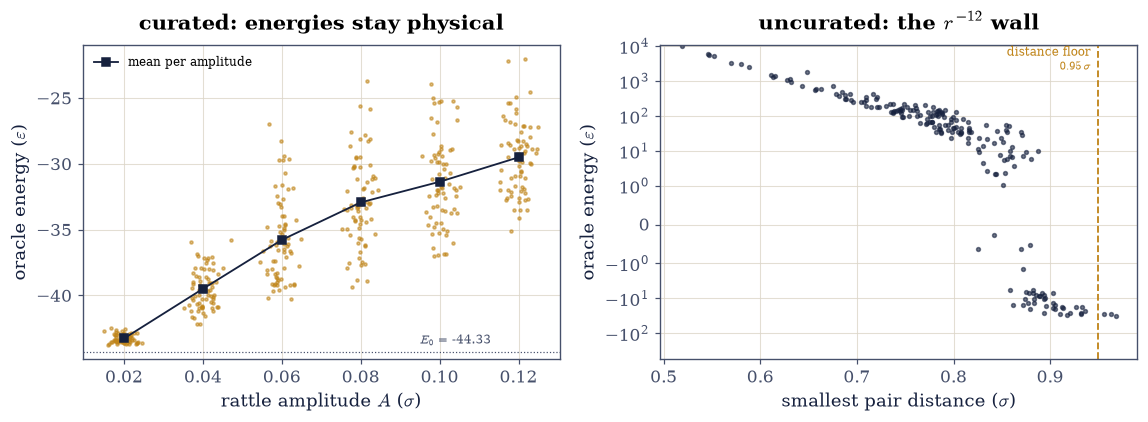

In [3]:
# (solution hidden on the public site)


In [4]:
validate.check(
    abs(E0 - E_LJ13) < 1e-3,
    "the 40-restart relaxation recovers the literature global minimum of the "
    "13-atom Lennard-Jones cluster, so the reference structure the whole dataset "
    "is rattled from is the true icosahedron",
    f"E0 = {E0:.6f} vs {E_LJ13} (Wales & Doye 1997)",
)
validate.check(
    0.5 < E1 - E0 < 5.0,
    "the restarts also found a genuinely distinct second basin at modest energy "
    "above the global minimum, available as the minority structure of Exercise 3",
    f"E1 - E0 = {E1 - E0:.3f} eps",
)
validate.check(
    E_POOL.max() < -20.0,
    "with the 0.95-sigma distance floor every curated energy stays within a few "
    "epsilon of the minimum, the regime a fit can actually represent",
    f"max curated E = {E_POOL.max():.2f} eps",
)
validate.check(
    E_CTRL.max() > 100.0,
    "while the uncurated control at the same nominal amplitude contains "
    "wall-energy outliers orders of magnitude above the physical range, which a "
    "quadratic loss would weight above everything else combined",
    f"max uncurated E = {E_CTRL.max():.1f} eps",
)
validate.check(
    bool(np.all(np.isfinite(X_POOL))) and bool(np.all(FEAT_SD > 0)),
    "and every fingerprint is finite with every feature carrying variance, so "
    "standardisation is well defined and no NaN reached the cutoff function",
    f"feature std in [{FEAT_SD.min():.3f}, {FEAT_SD.max():.3f}]",
)

✓  the 40-restart relaxation recovers the literature global minimum of the 13-atom Lennard-Jones cluster, so the reference structure the whole dataset is rattled from is the true icosahedron   [E0 = -44.326801 vs -44.326801 (Wales & Doye 1997)]
✓  the restarts also found a genuinely distinct second basin at modest energy above the global minimum, available as the minority structure of Exercise 3   [E1 - E0 = 2.855 eps]
✓  with the 0.95-sigma distance floor every curated energy stays within a few epsilon of the minimum, the regime a fit can actually represent   [max curated E = -22.06 eps]
✓  while the uncurated control at the same nominal amplitude contains wall-energy outliers orders of magnitude above the physical range, which a quadratic loss would weight above everything else combined   [max uncurated E = 10273.5 eps]
✓  and every fingerprint is finite with every feature carrying variance, so standardisation is well defined and no NaN reached the cutoff function   [feature std in [

True

---
## Exercise 2 — Kernel ridge regression, certified before trusted

The model is Eqs. {eq}`eq-lp-krr-model`–{eq}`eq-lp-rbf`: one kernel matrix, one
linear solve. That brevity is the point — nothing here is a black box, so every
behaviour of the model is a theorem about a linear system, and the two analytic
limits of $\lambda$ give certification gates that do not depend on any learned
quantity. Only after the implementation passes both limits do we let
cross-validation choose the hyperparameters it actually runs with.

**Part a)** Implement KRR as two functions: `krr_fit`, which assembles the RBF
kernel matrix of Eq. {eq}`eq-lp-rbf` by broadcasting
(`X[:, None, :] - X[None, :, :]`) and solves Eq. {eq}`eq-lp-krr-alpha` with
`np.linalg.solve` (never an explicit inverse: the solve is backward-stable and
cheaper), and `krr_predict`, which evaluates Eq. {eq}`eq-lp-krr-model` on new
points. **Write this one yourself** — the implementation is the lesson.

**Part b)** Certify the two limits on the curated dataset of Exercise 1, split
340/80 into train/test by `numpy.random.default_rng(2).permutation`. At
$\lambda = 10^{9}$ every prediction must equal the training mean $\bar{E}$; at
$\lambda = 10^{-10}$ on a 40-point training subset (small, so the solve stays
well conditioned) the model must interpolate its own training energies.

**Part c)** Choose $(\gamma, \lambda)$ by 5-fold cross-validation on the
training set (folds by `np.arange(n) % 5`), over the grid
$\gamma \in \{0.6, 1.2, 2.4, 4.8\}$ and $\lambda \in \{10^{-8}, \dots,
10^{-2}\}$, then report the test error of the chosen model against the
mean-predictor baseline.

**Part d)** Measure the numerical face of $\lambda$: the condition number
(`np.linalg.cond`) of $K + \lambda I$ on the full 340-point training set at
$\lambda = 10^{-6}$ and at the cross-validated $\lambda$. The ridge is doing
work here even though the labels carry no noise at all.

lambda -> inf : max |prediction - mean| = 4.83e-07 eps
lambda -> 0   : train rmse = 1.83e-05 eps  (label std 5.45)


CV pick: gamma = 4.8, lambda = 1e-04  (cv rmse 1.073)
test rmse 0.971 eps vs mean-predictor 5.415 eps (5.6x better)
cond(K + 1e-6 I) = 2.69e+08   cond(K + 1e-04 I) = 2.69e+06   ratio 100


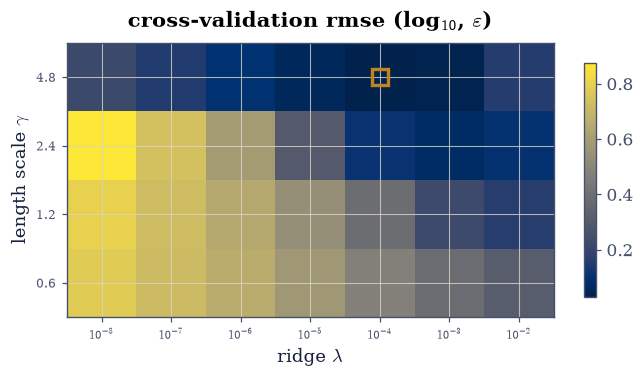

In [5]:
# (solution hidden on the public site)


In [6]:
validate.check(
    dev_inf < 1e-4,
    "in the infinite-ridge limit the fitted model collapses to the training-mean "
    "constant predictor, exactly as the crushed-coefficients algebra demands",
    f"max deviation {dev_inf:.2e} eps",
)
validate.check(
    interp_err < 0.02 * E_STD,
    "while in the vanishing-ridge limit the model interpolates its own training "
    "labels, the exact-fit theorem of the unregularised kernel system",
    f"train rmse {interp_err:.2e} vs label std {E_STD:.2f} eps",
)
validate.check(
    err_base / ERR_TEST > 2.5,
    "and the cross-validated model beats the mean-predictor baseline severalfold "
    "on held-out configurations, so the fingerprint carries genuine information "
    "about the energy",
    f"{err_base:.3f} / {ERR_TEST:.3f} = {err_base / ERR_TEST:.1f}x",
)
validate.check(
    cond_small / cond_cv > 50.0,
    "and the cross-validated ridge improves the kernel system's condition number "
    "a hundredfold even though the labels are noise-free: the ridge is chosen "
    "for conditioning, not against noise",
    f"cond ratio {cond_small / cond_cv:.0f}",
)

✓  in the infinite-ridge limit the fitted model collapses to the training-mean constant predictor, exactly as the crushed-coefficients algebra demands   [max deviation 4.83e-07 eps]
✓  while in the vanishing-ridge limit the model interpolates its own training labels, the exact-fit theorem of the unregularised kernel system   [train rmse 1.83e-05 vs label std 5.45 eps]
✓  and the cross-validated model beats the mean-predictor baseline severalfold on held-out configurations, so the fingerprint carries genuine information about the energy   [5.415 / 0.971 = 5.6x]
✓  and the cross-validated ridge improves the kernel system's condition number a hundredfold even though the labels are noise-free: the ridge is chosen for conditioning, not against noise   [cond ratio 100]


True

---
## Exercise 3 — Spending the labelling budget

In production the oracle is the expensive part: each label is a
density-functional calculation, so "how much data?" and "which data?" are
questions about compute budget. The learning curve answers the first — error
against training-set size, on a log-log axis where power-law learning appears
as a straight line. The second is the question
[§7.2](dimensionality-reduction.ipynb) closed with: farthest-point sampling
{cite}`imbalzano2018` selects configurations that *cover* descriptor space, and
whether coverage is what a fit wants was left open there. With a working model
we can now measure it, on the homogeneous pool and then on the harder case the
coverage argument was made for: a pool where one structure is rare.

**Part a)** Measure the learning curve of the cross-validated model from
Exercise 2: for each size $n \in \{10, 20, 40, 80, 160, 320\}$, train on 12
random subsets of the training set (`numpy.random.default_rng(100 + s).choice`
with `replace=False` for $s = 0, \dots, 11$) and record the *median* test rmse
(the median, because a quadratic error over few draws has a heavy tail).

**Part b)** Repeat with farthest-point sampling: for each $n$, train on the
first $n$ points of `farthest_point_sampling(Z_train, n, start=0)` from the
Setup and compare against the random median. Watch the smallest budget
separately: [§7.2](dimensionality-reduction.ipynb) showed that the earliest
farthest-point picks chase the corners of the distribution, and a training set
made *only* of corners is a real cost, not an artefact.

**Part c)** The imbalanced case: build a fresh two-basin pool with
`numpy.random.default_rng(3)` — for each amplitude in `AMPS_TRAIN`, 60 curated
rattles of the icosahedral reference and 10 of the second-basin structure from
Exercise 1, i.e. 420 configurations in all, then hold out the last 45 majority
and 25 minority configurations as a probe set and keep the first 315 + 35 as
the selection pool (a 10 % minority). Count how many of 12 random 10-point draws
(`numpy.random.default_rng(200 + s)`) contain *no* minority configuration at
all, at which selection number farthest-point sampling first picks a minority
point, and the minority fraction among its first 80 picks against the pool
fraction of 10 %.

n =  10: random median 3.763 eps   fps 4.394 eps   ratio 0.86
n =  20: random median 2.188 eps   fps 1.812 eps   ratio 1.21
n =  40: random median 1.471 eps   fps 1.294 eps   ratio 1.14
n =  80: random median 1.286 eps   fps 1.161 eps   ratio 1.11
n = 160: random median 1.077 eps   fps 1.004 eps   ratio 1.07
n = 320: random median 0.973 eps   fps 0.971 eps   ratio 1.00


random draws of 10: 7/12 contain zero minority configs (pool fraction 10%)
fps: first minority pick at #3; minority fraction in 80 picks 22%


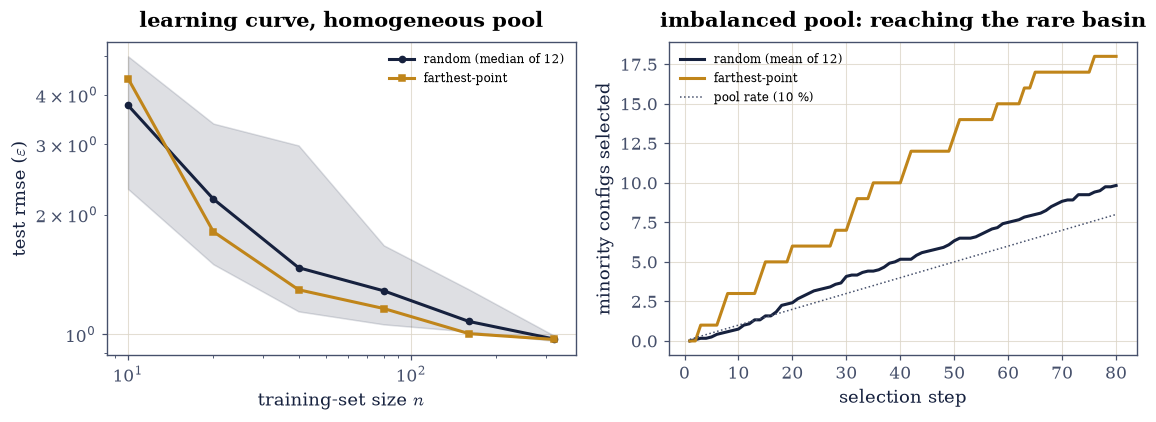

In [7]:
# (solution hidden on the public site)


In [8]:
mono_ok = bool(np.all(np.diff(RAND_MED) <= 0.02))
validate.check(
    mono_ok,
    "the median learning curve decreases monotonically with training-set size, "
    "as a curve measured with cross-validated hyperparameters and a median over "
    "draws should",
    " > ".join(f"{r:.2f}" for r in RAND_MED),
)
validate.check(
    RAND_MED[0] / RAND_MED[-1] > 2.0,
    "with the full budget improving the ten-point model severalfold, so more "
    "oracle calls genuinely buy accuracy in this regime",
    f"rmse(n=10)/rmse(n=320) = {RAND_MED[0] / RAND_MED[-1]:.1f}",
)
validate.check(
    bool(np.all(FPS_ERRS[1:] <= RAND_MED[1:] * 1.05)),
    "farthest-point selection matches or beats the random median at every "
    "budget beyond the smallest on the homogeneous pool (its advantage is "
    "modest there, and at n = 10 its corner-chasing start genuinely hurts — "
    "both halves of the honest answer to the question of §7.2)",
    "fps/random at n>=20: max "
    + f"{float(np.max(FPS_ERRS[1:] / RAND_MED[1:])):.2f}; at n=10 "
    + f"{FPS_ERRS[0] / RAND_MED[0]:.2f}",
)
validate.check(
    blind >= 2,
    "on the imbalanced pool a sizeable share of small random draws contain no "
    "minority-basin configuration at all, the failure mode coverage-based "
    "selection exists to prevent",
    f"{blind}/12 ten-point draws are minority-blind",
)
validate.check(
    FIRST_MINORITY <= 5,
    "while farthest-point sampling reaches the rare basin within its first few "
    "selections, because a rare structure is by definition far from everything "
    "already chosen in descriptor space",
    f"first minority pick at #{FIRST_MINORITY}",
)
validate.check(
    MINORITY_FRAC_FPS > 1.5 * POOL_FRAC,
    "and over-represents the minority basin well beyond its pool fraction, "
    "which is precisely the property a training set for a rare-event study "
    "needs",
    f"{MINORITY_FRAC_FPS:.0%} selected vs {POOL_FRAC:.0%} in the pool",
)

✓  the median learning curve decreases monotonically with training-set size, as a curve measured with cross-validated hyperparameters and a median over draws should   [3.76 > 2.19 > 1.47 > 1.29 > 1.08 > 0.97]
✓  with the full budget improving the ten-point model severalfold, so more oracle calls genuinely buy accuracy in this regime   [rmse(n=10)/rmse(n=320) = 3.9]
✓  farthest-point selection matches or beats the random median at every budget beyond the smallest on the homogeneous pool (its advantage is modest there, and at n = 10 its corner-chasing start genuinely hurts — both halves of the honest answer to the question of §7.2)   [fps/random at n>=20: max 1.00; at n=10 1.17]
✓  on the imbalanced pool a sizeable share of small random draws contain no minority-basin configuration at all, the failure mode coverage-based selection exists to prevent   [7/12 ten-point draws are minority-blind]
✓  while farthest-point sampling reaches the rare basin within its first few selections, because 

True

---
## Exercise 4 — Where the model lies

A fitted potential returns a number for *any* input, and nothing in the number
says whether the model has ever seen anything like the query. This is the
central operational danger of machine-learning potentials: a molecular-dynamics
run that wanders outside the training domain does not crash, it just quietly
produces wrong forces. The theory section predicted the failure mode exactly —
far from the training set, every kernel entry in Eq. {eq}`eq-lp-krr-model`
is small and the prediction relaxes toward the training mean $\bar{E}$ — and
it also named the cheap diagnostic: the distance from the query to its nearest
training neighbour in descriptor space.

**Part a)** Build the out-of-domain probe: with `numpy.random.default_rng(4)`,
40 curated rattles of the icosahedral reference at each amplitude in
`AMPS_FAR` $= \{0.18, 0.24\}\,\sigma$ (same `DMIN` floor, so every probe is a
physical configuration; what changes is only the distance from the training
amplitudes). Predict their energies with the Exercise 2 model and compare the
rmse against the in-domain test error, and compute the Spearman rank
correlation (`scipy.stats.spearmanr`) between predicted and true energies to
ask whether the model at least ranks the probes correctly.

**Part b)** Compute the red flag that would have caught it: for every
in-domain test point and every probe, the Euclidean distance to the nearest
training point in standardised descriptor space (one broadcast, `min` over the
training axis). Compare the two distributions and their medians.

rmse: in-domain 0.971 eps, out-of-domain 9.610 eps (9.9x worse)
out-of-domain rank correlation (Spearman) -0.008
nearest-training distance, median: in-domain 0.139, out-of-domain 3.773 (27x)


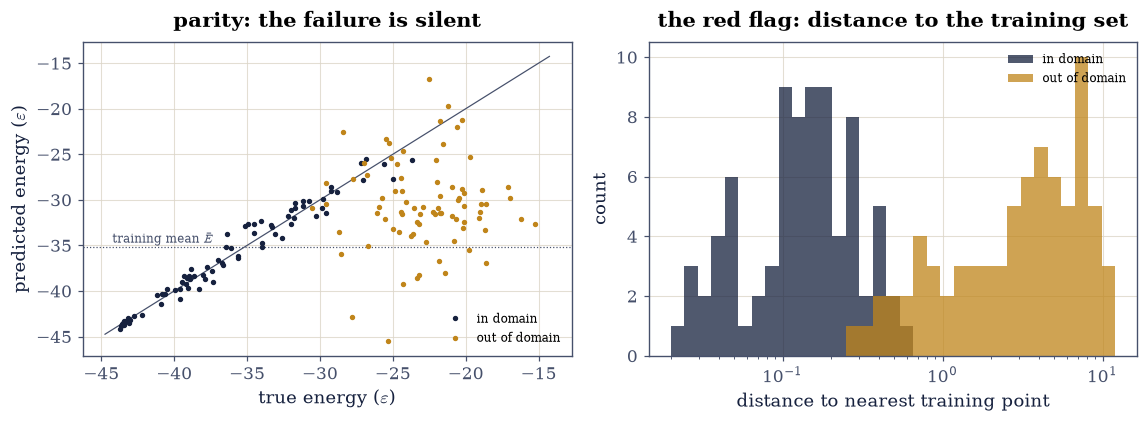

In [9]:
# (solution hidden on the public site)


In [10]:
validate.check(
    ERR_FAR / ERR_TEST > 3.0,
    "outside the training amplitudes the prediction error grows severalfold "
    "over the in-domain test error even though every probe is a perfectly "
    "physical configuration, the silent-extrapolation failure the theory "
    "section predicted",
    f"{ERR_FAR:.2f} / {ERR_TEST:.2f} = {ERR_FAR / ERR_TEST:.1f}x",
)
validate.check(
    RHO_FAR < 0.2,
    "and the out-of-domain predictions carry essentially no rank information "
    "about the true energies: the model does not merely lose precision out "
    "there, it stops ordering configurations correctly at all",
    f"Spearman rho = {RHO_FAR:+.3f}",
)
validate.check(
    MED_FAR / MED_TEST > 5.0,
    "while the nearest-training-neighbour distance separates the two regimes "
    "by an order of magnitude in the median, so the one-number diagnostic "
    "would have flagged the unreliable predictions before use",
    f"median {MED_FAR:.2f} vs {MED_TEST:.2f} ({MED_FAR / MED_TEST:.0f}x)",
)

✓  outside the training amplitudes the prediction error grows severalfold over the in-domain test error even though every probe is a perfectly physical configuration, the silent-extrapolation failure the theory section predicted   [9.61 / 0.97 = 9.9x]
✓  and the out-of-domain predictions carry essentially no rank information about the true energies: the model does not merely lose precision out there, it stops ordering configurations correctly at all   [Spearman rho = -0.008]
✓  while the nearest-training-neighbour distance separates the two regimes by an order of magnitude in the median, so the one-number diagnostic would have flagged the unreliable predictions before use   [median 3.77 vs 0.14 (27x)]


True

---
## Notebook summary

- A machine-learning potential is a pipeline, and the first stage is editorial:
  the curated pool stayed within $\sim 20\,\varepsilon$ of the icosahedral
  minimum, while unrestricted rattling at the *same nominal amplitude* produced
  wall energies four orders of magnitude larger — single configurations that
  would dominate a quadratic loss outright.
- Kernel ridge regression is exact linear algebra, and that made it
  certifiable: the fitted model reproduced both analytic ridge limits (mean
  predictor and exact interpolation) before any hyperparameter was chosen, and
  the cross-validated model then beat the mean predictor more than fivefold on
  held-out configurations.
- The ridge earned its place with noise-free labels: cross-validation selected
  $\lambda = 10^{-4}$ for *conditioning*, improving the kernel system's
  condition number a hundredfold over a nearly unregularised solve.
- The learning curve fell monotonically, nearly fourfold from 10 to 320
  labels, and farthest-point sampling answered the question §7.2 left open
  with both halves of the truth: on a homogeneous pool coverage helps only
  modestly and its corner-chasing start actually *hurts* at the smallest
  budget, but on an imbalanced pool it reached the 10 % minority basin by its
  third pick, while more than half of the small random draws never saw that
  basin at all.
- Out of domain the model failed silently: physically reasonable probes at
  twice the training amplitude were predicted with ten times the in-domain
  error and essentially no rank correlation, while the distance to the
  nearest training point separated the regimes by well over an order of
  magnitude — the one cheap number that turns a silent failure into a loud
  one.

## Outlook

- **Forces, not just energies.** A potential for dynamics must predict forces,
  and Eq. {eq}`eq-lp-krr-model` obliges: the gradient of a kernel expansion is
  analytic, so forces come from the same coefficients, and training on forces
  (3N labels per oracle call instead of one) is the standard way to make an
  expensive label go further {cite}`bartok2010`.
- **Better representations.** Our eight global G2 features cannot separate
  everything ([§7.1](structural-descriptors.ipynb) proved specific blind
  spots); production models use per-atom descriptor sets (many symmetry
  functions {cite}`behler2007`, or SOAP {cite}`bartok2013`) with the energy as
  a sum of atomic contributions, which also makes the model size-transferable.
- **Active learning.** The red flag of Exercise 4 upgrades naturally from
  diagnostic to strategy: run the model, flag the configurations it is least
  sure of, send exactly those to the oracle, retrain. That loop, seeded by a
  farthest-point start like the one measured in Exercise 3, is how modern
  training sets are actually assembled {cite}`imbalzano2018`.
- **The oracle in production.** Everything here transfers with the
  Lennard-Jones oracle swapped for density-functional theory — the workflows
  of [§4.2](../04-electronic-structure/oxygen-triplet.ipynb) and
  [§6.1](../06-reactions-free-energy/ethanol-dehydration.ipynb) are precisely
  what the labels cost, which is why dataset curation and label budgeting are
  research skills rather than bookkeeping.

### References

```{bibliography}
:filter: docname in docnames
```

In [11]:
from ecp.style import footer

footer()

<ECP header: 1690 chars of HTML>